<a href="https://colab.research.google.com/github/gilIolgenblum/ProteinCrowding/blob/main/tutorials/03b_ternary_plots_showcase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ternary Model: Plotting Showcase

This notebook demonstrates all the plotting functionalities available in the `TernaryPlotter` for analyzing and visualizing the thermodynamics of the ternary crowding model.

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/ProteinCrowding.git
    # Change the working directory to the repository root
    os.chdir('/content/ProteinCrowding')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/ProteinCrowding/src')

Cloning into 'ProteinCrowding'...
remote: Enumerating objects: 456, done.
remote: Counting objects: 100% (456/456), done.
remote: Compressing objects: 100% (272/272), done.
remote: Total 456 (delta 234), reused 384 (delta 179), pack-reused 0 (from 0)
Receiving objects: 100% (456/456), 14.83 MiB | 19.90 MiB/s, done.
Resolving deltas: 100% (234/234), done.
Obtaining file:///content/ProteinCrowding
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fh_crowding (pyproject.toml) ... done
  Created wheel for fh_crowding: filename=fh_crowding-0.1.0-0.editable-py3-none-any.whl size=3165 sha256=5fbda8bd16dd9f7004c23c835fa73a6d22189ad84b52a155048ccd6a40d46d33
  Stored in directory: /tmp/pip-ephem-wheel-cache-eztmz6d6/wheels/8e/87/c6/59b0297bcdbde056eefb789604b557fd569845c8580cefb7a2
Successfully built fh_crowding


In [2]:
import fh_crowding
import matplotlib.pyplot as plt
import numpy as np
from fh_crowding.plotting import TernaryPlotter

# Define Protein
protein = fh_crowding.Protein(SASA=242.6)

# Combine into a mixture.
mixture = fh_crowding.CosoluteMixture(
    nu2=2.479, nu3=3.980,
    chi12=0.610, chi13=-0.680, chi23=0.963,
    chiTS12=-3.650, chiTS13=-5.708, chiTS23=-38.810
)

# Initialize the model
model = fh_crowding.TernaryCrowdingModel(
    protein=protein,
    cosolutes=mixture,
    eps2=-0.3401,
    eps3=-0.0006,
    epsTS2=-0.7824,
    epsTS3=0.5958,
    eps23=0.3057,
    epsTS23=-1.9780,
    phi2_max=0.23,
    phi3_max=0.23,
    dphi2=0.01,
    dphi3=0.01,
    T=298.15
)

# Solve the thermodynamic equilibrium across the 2D grid
model.solve_equil(print_msg=False)

# Initialize the plotter
plotter = TernaryPlotter(model)
print("Model initialized and solved. Plotter ready.")

Model initialized and solved. Plotter ready.


## Folding Free Energy ($\Delta\Delta G$)
The `plot_ddG` method visualizes the total folding free energy $\Delta\Delta G$ as well as its individual components (excluded volume $\nu$, solvent-cosolute interactions $\chi$, and soft interactions $\varepsilon$) across the concentration grid.

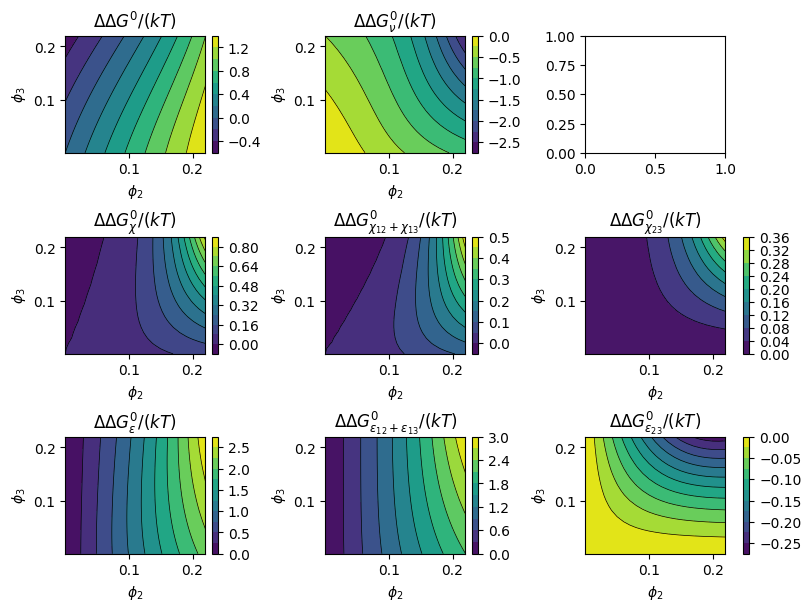

In [3]:
fig = plotter.plot_ddG()
plt.show()

## Folding Enthalpy ($\Delta\Delta H$)
The `plot_ddH` method visualizes the enthalpic contributions of the folding process across the ternary concentration grid.

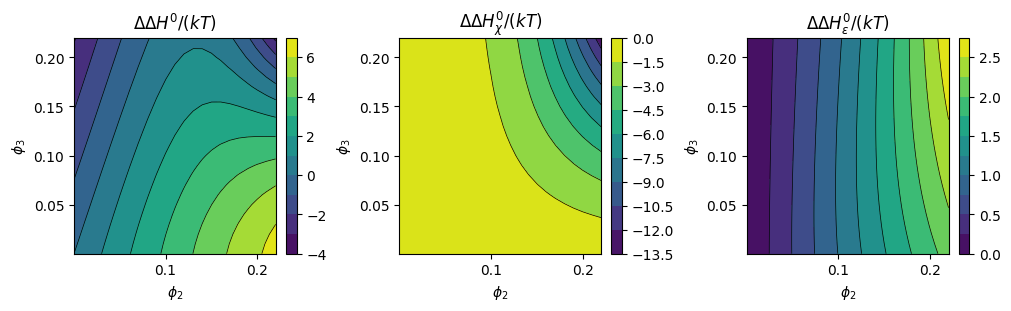

In [4]:
fig = plotter.plot_ddH()
plt.show()

## Folding Entropy ($T\Delta\Delta S$)
The `plot_TddS` method shows the entropic contributions ($T\Delta\Delta S$) of the folding process.

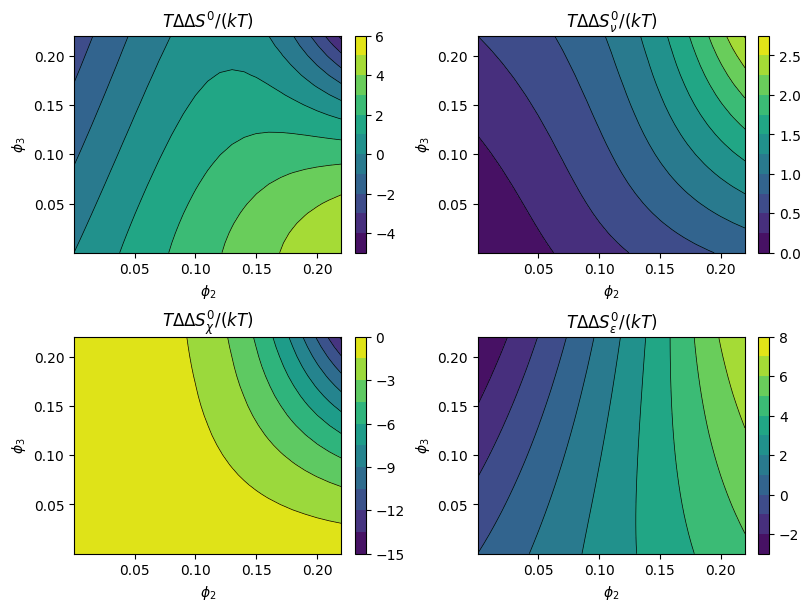

In [5]:
fig = plotter.plot_TddS()
plt.show()

## Free Energy in Chemical Potential Space ($\Delta\Delta G(\mu)$)
The `plot_ddG_mu` method maps the folding free energy onto the chemical potential ($\mu_2, \mu_3$) grid instead of the volume fraction grid.

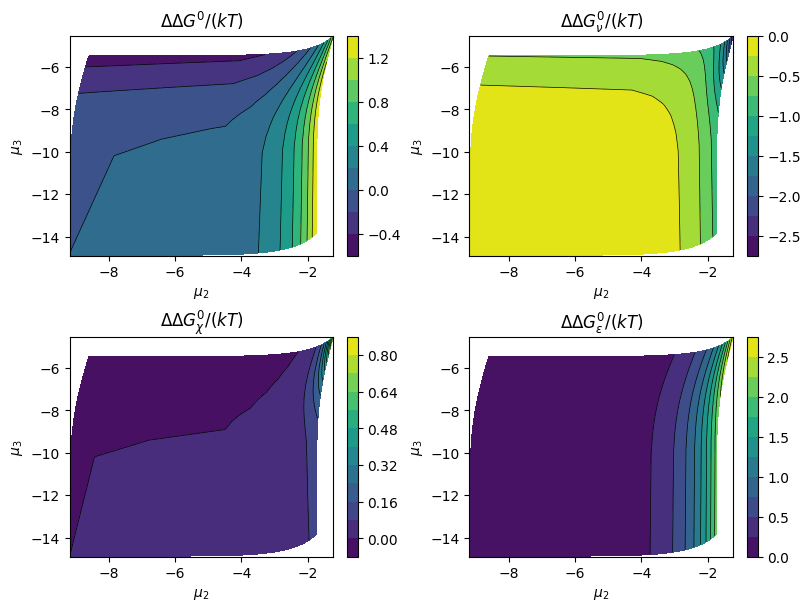

In [6]:
fig = plotter.plot_ddG_mu()
plt.show()

## Preferential Interaction Parameters ($\Gamma$)
The `plot_Gamma` method visualizes the Preferential Interaction Parameters (PCIs) for each cosolute, indicating accumulation ($\Gamma > 0$) or depletion ($\Gamma < 0$) around the protein surface.

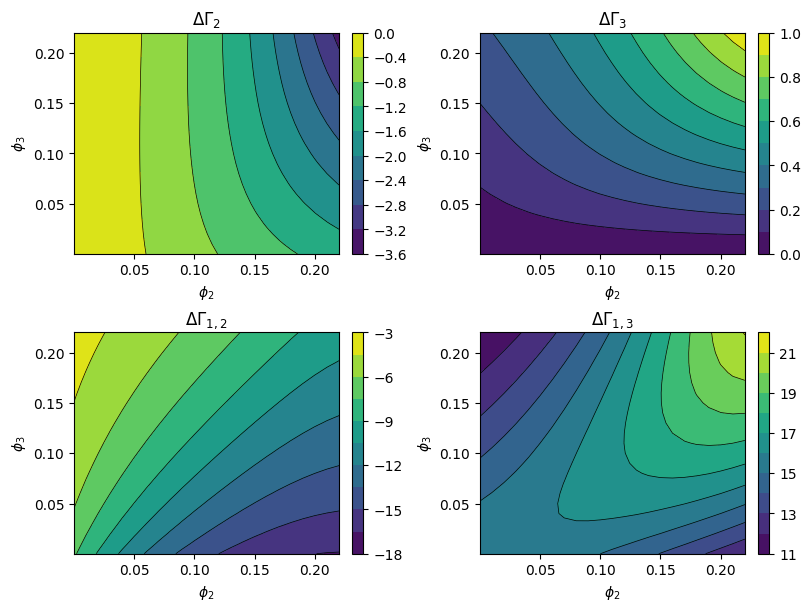

In [7]:
fig = plotter.plot_Gamma()
plt.show()

## Preferential Interactions in Chemical Potential Space ($\Gamma(\mu)$)
The `plot_Gamma_mu` method maps the Preferential Interaction Parameters (PCIs) onto the chemical potential grid.

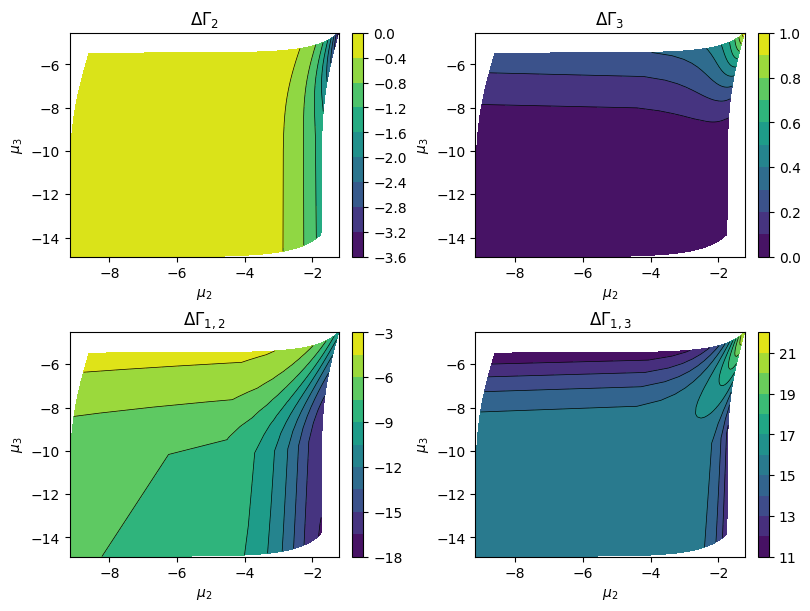

In [8]:
fig = plotter.plot_Gamma_mu()
plt.show()

## Protein Domain Size ($M_s$)
The `plot_Ms` method visualizes the sub-domains volumes ($Ms_2$, $Ms_3$) scaled to the total protein domain volume ($M_s$) as the cosolute concentrations change.

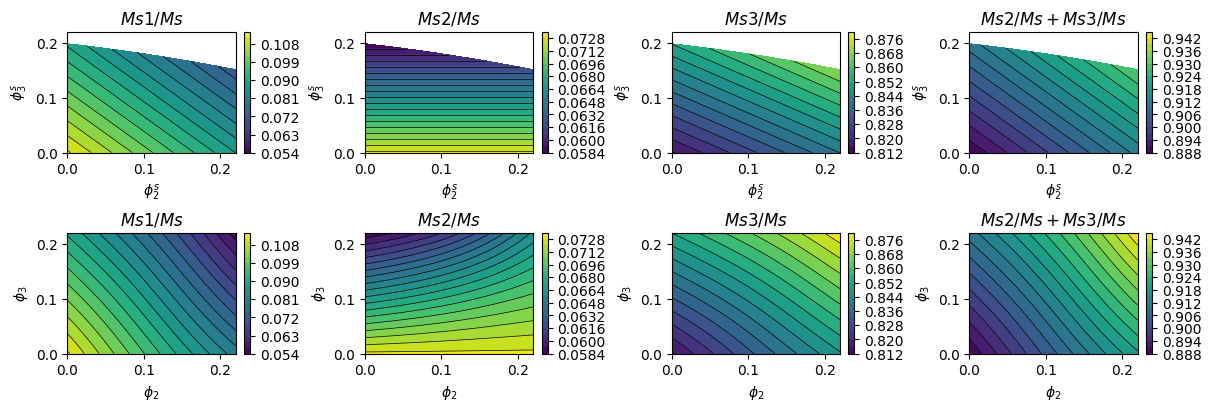

In [9]:
fig = plotter.plot_Ms()
plt.show()

## Volume Fractions within the Protein Domain ($\phi^s$)
The `plot_phiS` method visualizes the local volume fractions ($\phi_1^s, \phi_2^s, \phi_3^s$) of the solvent and cosolutes exactly at the protein surface domain.

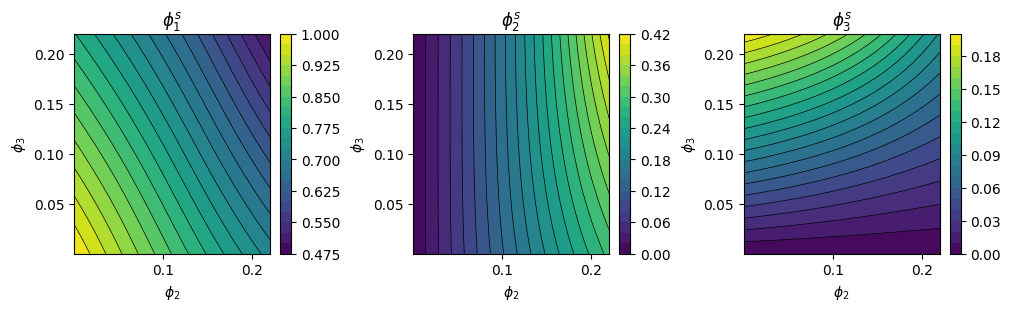

In [10]:
fig = plotter.plot_phiS()
plt.show()

## Chemical Potentials within Sub-domain 2 ($\mu^{s2}$)
The `plot_mus2` method shows the local chemical potentials of the components within the sub-domain 2 surrounding the protein.

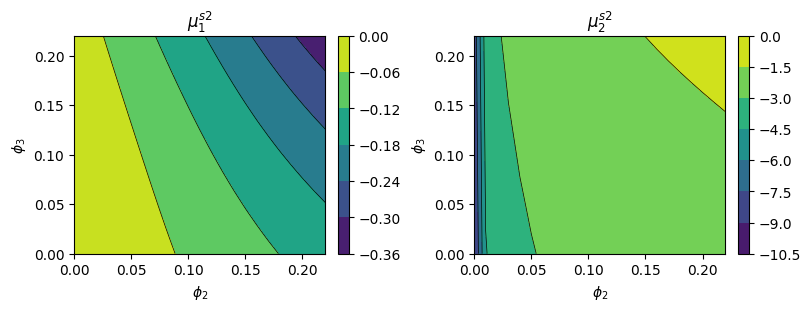

In [11]:
fig = plotter.plot_mus2()
plt.show()

## Chemical Potentials within Sub-domain 3 ($\mu^{s3}$)
The `plot_mus3` method shows the local chemical potentials within sub-domain 3.

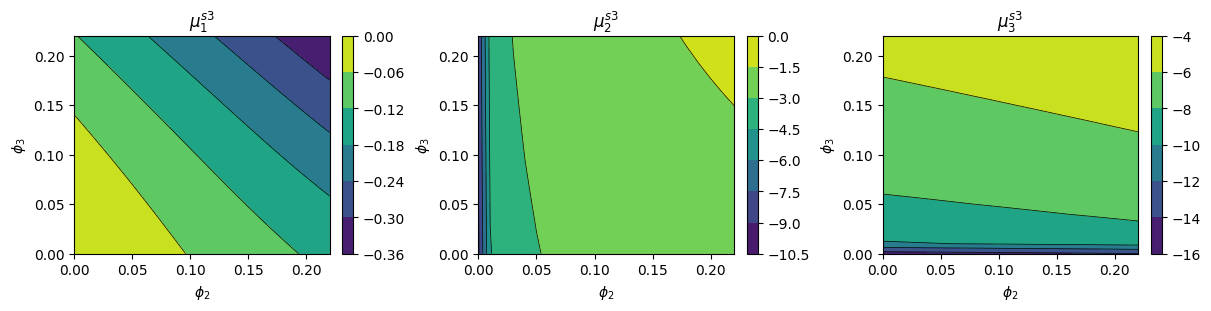

In [12]:
fig = plotter.plot_mus3()
plt.show()

## Equilibrium Condition Convergence
The `plot_equil_cond` method provides a convergence map of the fsolve optimization, useful for diagnosing regions where the equilibrium conditions failed to properly converge.

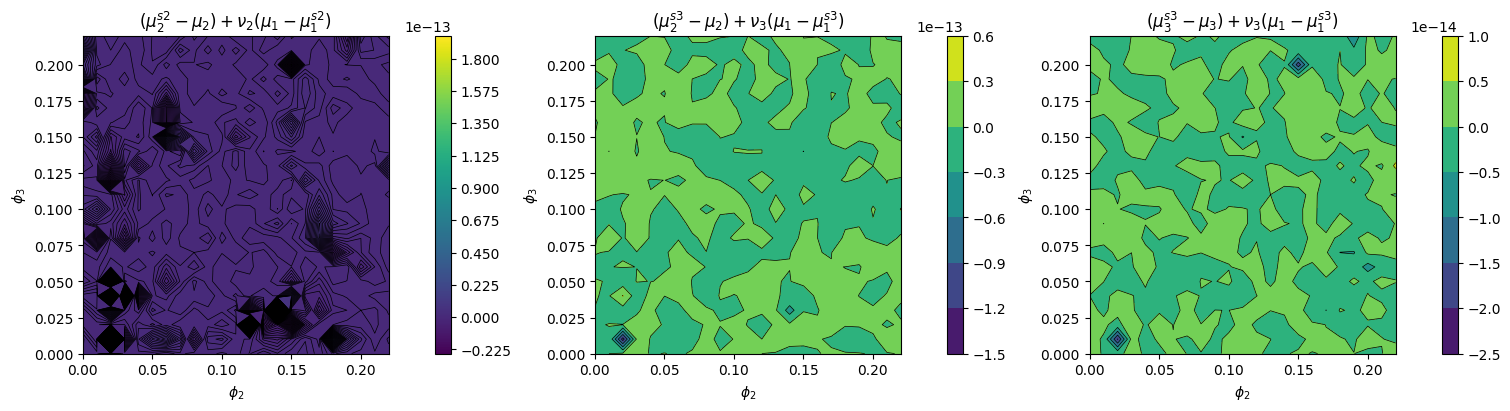

In [13]:
fig = plotter.plot_equil_cond()
plt.show()

## Mixing Entropy ($T\Delta S_{mix}$)
The `plot_TdS_mix` method maps out the components of the FH mixing entropy taking place within the protein interaction sub-domains.

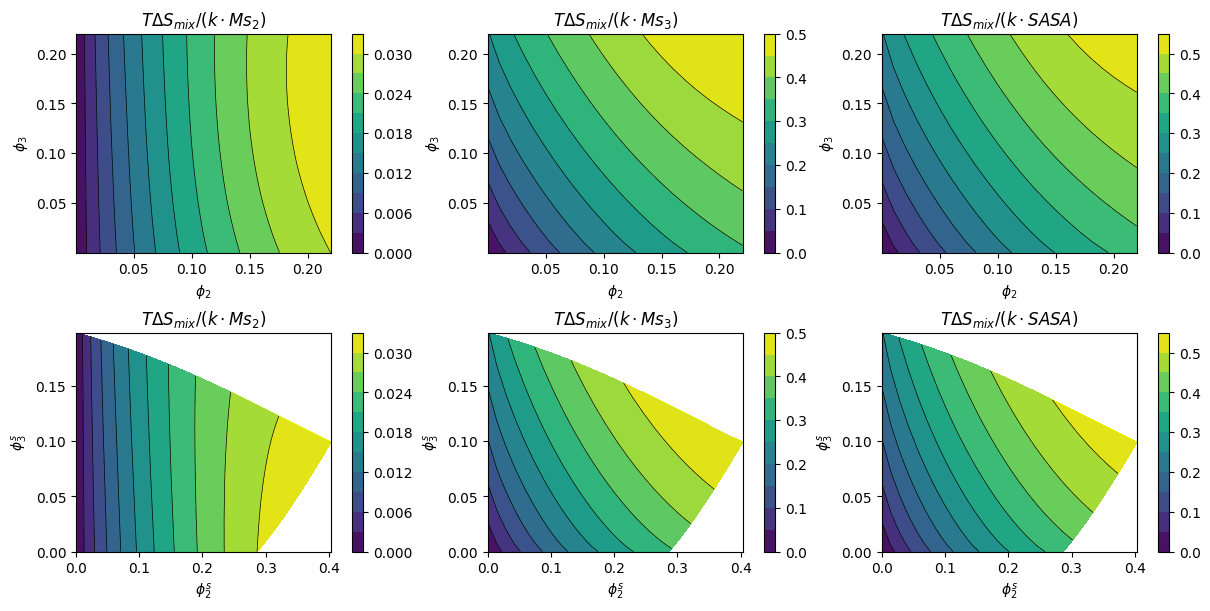

In [14]:
fig = plotter.plot_TdS_mix()
plt.show()

## Mixing Free Energy ($\Delta G_{mix}$)
The `plot_dG_mix` method maps out the mixing free energy occurring inside the protein sub-domains.

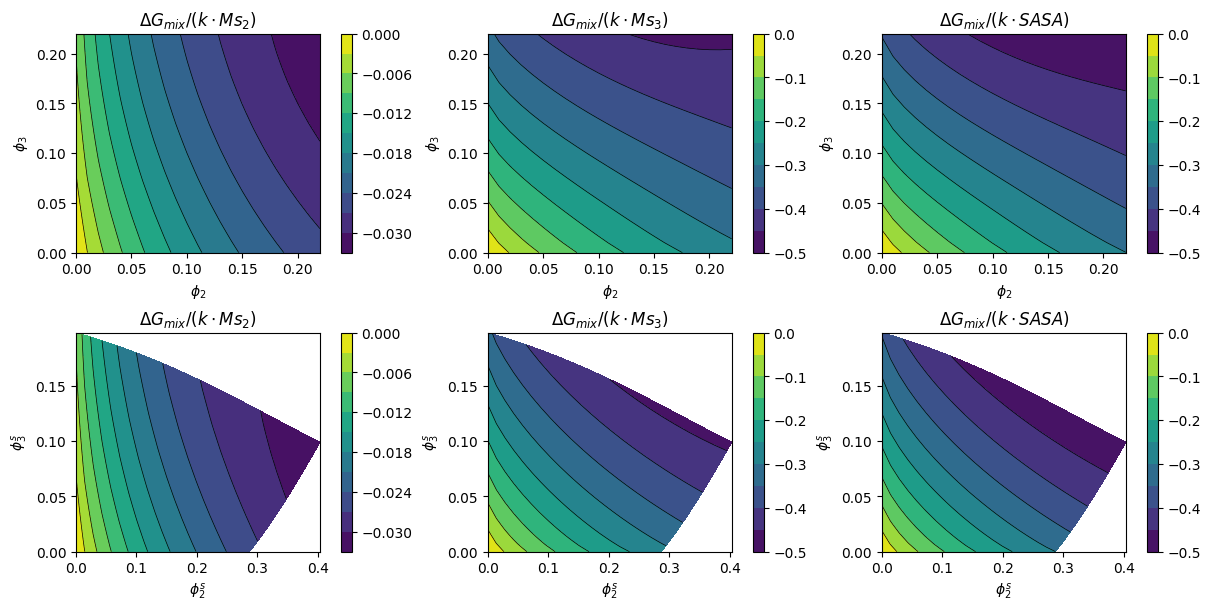

In [15]:
fig = plotter.plot_dG_mix()
plt.show()